In [1]:
import os
import glob
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import timm
from torch.utils.data import Dataset, DataLoader, random_split
from torch.optim.lr_scheduler import OneCycleLR
from torchvision import models, transforms
from sklearn.metrics import confusion_matrix, roc_curve, auc, roc_auc_score

warnings.filterwarnings('ignore')
torch.manual_seed(42)
np.random.seed(42)

DEVICE      = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
NUM_CLASSES = 3
CLASSES     = ['no', 'sphere', 'vort']
CLASS_DICT  = {0: 'no substructure', 1: 'spherical substructure', 2: 'vortex substructure'}
TRAIN_DIR   = '/kaggle/input/datasets/anukultiwari/deeplense/dataset/train'
VAL_DIR     = '/kaggle/input/datasets/anukultiwari/deeplense/dataset/val'

print(f'Device: {DEVICE}')

Device: cuda


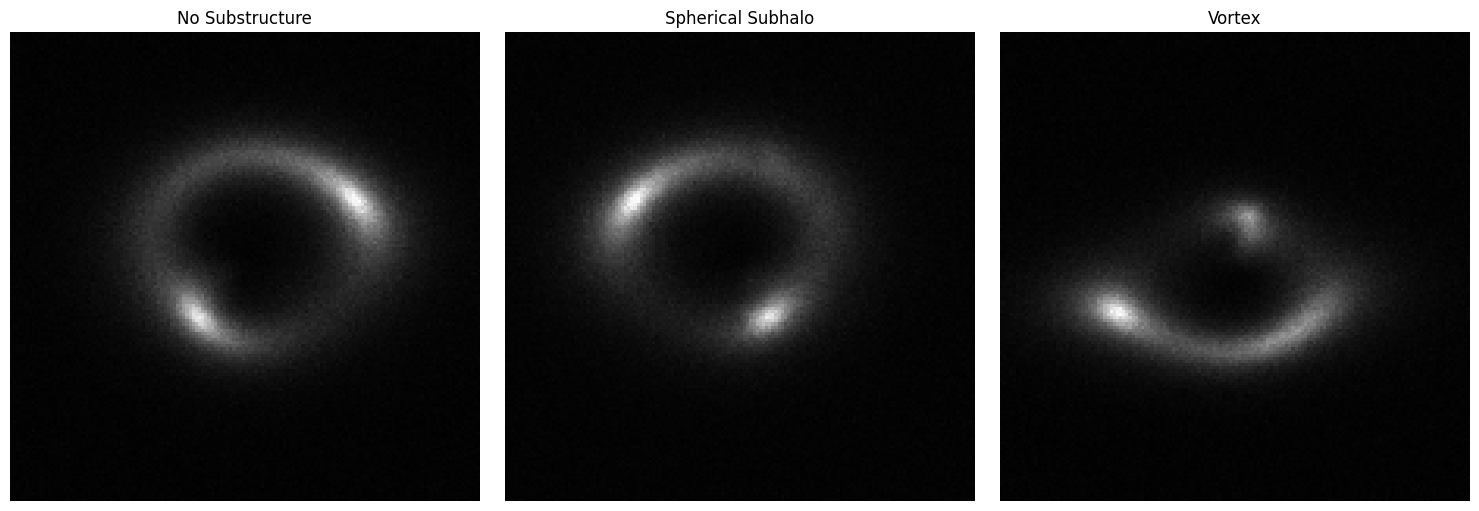

In [2]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for ax, cls, title in zip(axes, CLASSES, ['No Substructure', 'Spherical Subhalo', 'Vortex']):
    ax.imshow(np.load(os.path.join(TRAIN_DIR, cls, '1.npy'))[0], cmap='gray')
    ax.set_title(title)
    ax.axis('off')
plt.tight_layout()
plt.show()

In [3]:
def make_transform(split):
    aug = [transforms.Resize(256), transforms.CenterCrop(224)]
    if split == 'train':
        aug += [transforms.RandomRotation(10), transforms.RandomHorizontalFlip(0.5)]
    aug += [transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])]
    return transforms.Compose(aug)


class LensingDataset(Dataset):
    def __init__(self, root_dir, split='train'):
        self.transform    = make_transform(split)
        self.classes      = sorted(os.listdir(root_dir))
        self.class_to_idx = {c: i for i, c in enumerate(self.classes)}
        self.samples      = [
            (fp, self.class_to_idx[cls])
            for cls in self.classes
            if os.path.isdir(os.path.join(root_dir, cls))
            for fp in glob.glob(os.path.join(root_dir, cls, '*.npy'))
        ]
    def __len__(self):
        return len(self.samples)
    def __getitem__(self, idx):
        fp, label = self.samples[idx]
        image = torch.from_numpy(np.load(fp)).float()
        if image.shape[0] == 1:
            image = image.repeat(3, 1, 1)
        image = self.transform(image)
        return image, label


def build_loaders(batch_size=32, num_workers=4):
    full_train = LensingDataset(TRAIN_DIR, split='train')
    n_train    = int(0.9 * len(full_train))
    train_sub, val_sub = random_split(
        full_train, [n_train, len(full_train) - n_train],
        generator=torch.Generator().manual_seed(42)
    )
    val_sub.dataset = LensingDataset(TRAIN_DIR, split='val')
    test_ds  = LensingDataset(VAL_DIR, split='val')
    train_ld = DataLoader(train_sub, batch_size=batch_size, shuffle=True,  num_workers=num_workers)
    val_ld   = DataLoader(val_sub,   batch_size=batch_size, shuffle=False, num_workers=num_workers)
    test_ld  = DataLoader(test_ds,   batch_size=batch_size, shuffle=False, num_workers=num_workers)
    print(f'  train={len(train_sub):,}  val={len(val_sub):,}  test={len(test_ds):,}')
    return train_ld, val_ld, test_ld, full_train.class_to_idx


train_ld, val_ld, test_ld, class_to_idx = build_loaders(batch_size=32)

  train=27,000  val=3,000  test=7,500


In [4]:
def train_model(model, train_loader, val_loader, criterion, optimizer, num_epochs, model_name):
    model.to(DEVICE)
    best_val_acc = 0.0
    history = {'train_loss': [], 'val_loss': []}
    for epoch in range(num_epochs):
        model.train()
        running_loss = correct = total = 0
        for inputs, labels in tqdm(train_loader, desc=f'Epoch {epoch+1}/{num_epochs} [Train]'):
            inputs, labels = inputs.to(DEVICE), labels.to(DEVICE)
            optimizer.zero_grad()
            outputs = model(inputs)
            loss    = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            running_loss += loss.item() * inputs.size(0)
            _, predicted  = torch.max(outputs, 1)
            total        += labels.size(0)
            correct      += (predicted == labels).sum().item()
        history['train_loss'].append(running_loss / len(train_loader.dataset))
        model.eval()
        val_loss = val_correct = val_total = 0
        with torch.no_grad():
            for inputs, labels in tqdm(val_loader, desc=f'Epoch {epoch+1}/{num_epochs} [Val]'):
                inputs, labels = inputs.to(DEVICE), labels.to(DEVICE)
                outputs        = model(inputs)
                loss           = criterion(outputs, labels)
                val_loss      += loss.item() * inputs.size(0)
                _, predicted   = torch.max(outputs, 1)
                val_total     += labels.size(0)
                val_correct   += (predicted == labels).sum().item()
        val_epoch_loss = val_loss / len(val_loader.dataset)
        val_epoch_acc  = val_correct / val_total
        history['val_loss'].append(val_epoch_loss)
        print(f'Epoch {epoch+1}/{num_epochs}:  '
              f'Train Loss: {history["train_loss"][-1]:.4f}  '
              f'Val Loss: {val_epoch_loss:.4f}  Val Acc: {val_epoch_acc:.4f}')
        if val_epoch_acc > best_val_acc:
            best_val_acc = val_epoch_acc
            torch.save(model.state_dict(), f'best_{model_name}.pt')
            print(f'Best model saved: {best_val_acc:.4f}')
    return model, history


def evaluate_model(model, test_loader, criterion):
    model.eval()
    test_correct = test_total = 0
    all_preds, all_labels, all_probs = [], [], []
    with torch.no_grad():
        for inputs, labels in tqdm(test_loader, desc='Evaluating'):
            inputs, labels = inputs.to(DEVICE), labels.to(DEVICE)
            outputs        = model(inputs)
            probs          = F.softmax(outputs, dim=1)
            _, predicted   = torch.max(outputs, 1)
            test_total   += labels.size(0)
            test_correct += (predicted == labels).sum().item()
            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
            all_probs.extend(probs.cpu().numpy())
    test_acc      = test_correct / test_total
    all_labels_np = np.array(all_labels)
    all_probs_np  = np.array(all_probs)
    fpr, tpr, roc_auc = {}, {}, {}
    for i in range(NUM_CLASSES):
        fpr[i], tpr[i], _ = roc_curve((all_labels_np == i).astype(int), all_probs_np[:, i])
        roc_auc[i]        = auc(fpr[i], tpr[i])
    macro_auc = sum(roc_auc.values()) / NUM_CLASSES
    print(f'Accuracy: {test_acc:.4f}  Macro AUC: {macro_auc:.4f}')
    return test_acc, macro_auc, roc_auc, fpr, tpr, all_labels_np, np.array(all_preds), all_probs_np


def plot_roc(fpr, tpr, roc_auc, title):
    plt.figure(figsize=(8, 6))
    for i in fpr:
        plt.plot(fpr[i], tpr[i], lw=2, label=f'{CLASS_DICT[i]} (AUC = {roc_auc[i]:.4f})')
    plt.plot([0, 1], [0, 1], 'k--', lw=1)
    plt.xlim([0, 1]); plt.ylim([0, 1.05])
    plt.xlabel('False Positive Rate'); plt.ylabel('True Positive Rate')
    plt.title(f'ROC Curve - {title}')
    plt.legend(loc='lower right'); plt.grid(True)
    plt.tight_layout(); plt.show()


def plot_cm(labels, preds, title):
    cm          = confusion_matrix(labels, preds)
    class_names = [k for k, v in sorted(class_to_idx.items(), key=lambda x: x[1])]
    plt.figure(figsize=(7, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names)
    plt.xlabel('Predicted'); plt.ylabel('True')
    plt.title(f'Confusion Matrix - {title}')
    plt.tight_layout(); plt.show()


def plot_history(train_loss, val_loss, title):
    plt.figure(figsize=(7, 4))
    plt.plot(train_loss, label='Train Loss')
    plt.plot(val_loss,   label='Val Loss')
    plt.xlabel('Epoch'); plt.ylabel('Loss')
    plt.title(f'Loss Curve - {title}')
    plt.legend(); plt.grid(alpha=0.3)
    plt.tight_layout(); plt.show()

In [5]:
class SimpleModel(nn.Module):
    def __init__(self):
        super(SimpleModel, self).__init__()
        self.resnet    = timm.create_model('resnet18', pretrained=True, drop_rate=0.3)
        self.resnet.fc = nn.Linear(in_features=512, out_features=3, bias=True)
    def forward(self, x):
        return self.resnet(x)


EPOCHS_R18    = 30
PATIENCE      = 5
meramodel     = SimpleModel().to(DEVICE)
criterion_r18 = nn.CrossEntropyLoss()
optimizer_r18 = torch.optim.RAdam(meramodel.parameters(), lr=0.01, weight_decay=1e-4)
scheduler_r18 = OneCycleLR(
    optimizer_r18, max_lr=1e-2, epochs=EPOCHS_R18,
    steps_per_epoch=len(train_ld),
    pct_start=0.1, anneal_strategy='cos', final_div_factor=100
)

trainloss_r18, valloss_r18 = [], []
bestloss           = np.inf
best_acc_r18       = best_auc_r18 = 0.0
best_per_class_r18 = []
patience_counter   = 0

for epoch in range(EPOCHS_R18):
    print(f'Epoch {epoch+1}/{EPOCHS_R18}')
    print('-' * 60)
    meramodel.train()
    iter_loss = counter = 0
    for inputs, labels in tqdm(train_ld):
        inputs, labels = inputs.to(DEVICE), labels.to(DEVICE)
        optimizer_r18.zero_grad()
        out  = meramodel(inputs)
        loss = criterion_r18(F.log_softmax(out, dim=1), labels)
        loss.backward()
        optimizer_r18.step()
        iter_loss += loss.item() * inputs.shape[0]
        counter   += inputs.shape[0]
    trainl = iter_loss / counter
    trainloss_r18.append(trainl)

    meramodel.eval()
    iter_loss = counter = correct = 0
    y_true, y_scores = [], []
    for inputs, labels in tqdm(test_ld):
        inputs, labels = inputs.to(DEVICE), labels.to(DEVICE)
        with torch.no_grad():
            out  = meramodel(inputs)
            loss = criterion_r18(F.log_softmax(out, dim=1), labels)
            iter_loss += loss.item() * inputs.shape[0]
            correct   += (torch.argmax(F.log_softmax(out, dim=1), dim=1) == labels).sum().item()
            y_true.extend(labels.cpu().numpy())
            y_scores.extend(F.softmax(out, dim=1).cpu().numpy())
        counter += inputs.shape[0]
    vall      = iter_loss / counter
    acc       = correct / counter
    y_true    = np.array(y_true)
    y_scores  = np.array(y_scores)
    per_class = [roc_auc_score(y_true == i, y_scores[:, i]) for i in range(NUM_CLASSES)]
    auc_score = np.mean(per_class)
    valloss_r18.append(vall)
    scheduler_r18.step()
    print(f'TrainLoss: {trainl:.4f}  ValLoss: {vall:.4f}  Accuracy: {acc:.4f}  AUC: {auc_score:.4f}')
    if bestloss > vall:
        bestloss           = vall
        best_acc_r18       = acc
        best_auc_r18       = auc_score
        best_per_class_r18 = per_class
        patience_counter   = 0
        torch.save({'model': meramodel.state_dict(), 'optimizer': optimizer_r18.state_dict()},
                   'best_resnet18.model')
        print('Best model saved.')
    print('=' * 60)

model.safetensors:   0%|          | 0.00/46.8M [00:00<?, ?B/s]

Epoch 1/30
------------------------------------------------------------


100%|██████████| 235/235 [00:11<00:00, 21.36it/s]


TrainLoss: 1.0987  ValLoss: 1.0798  Accuracy: 0.3947  AUC: 0.5837
Best model saved.
Epoch 2/30
------------------------------------------------------------


100%|██████████| 235/235 [00:04<00:00, 56.26it/s]


...

TrainLoss: 0.1439  ValLoss: 0.1808  Accuracy: 0.9343  AUC: 0.9899
Epoch 29/30
------------------------------------------------------------


100%|██████████| 235/235 [00:04<00:00, 54.89it/s]


TrainLoss: 0.1429  ValLoss: 0.2161  Accuracy: 0.9323  AUC: 0.9876
Epoch 30/30
------------------------------------------------------------


100%|██████████| 235/235 [00:04<00:00, 54.10it/s]

TrainLoss: 0.1413  ValLoss: 0.1671  Accuracy: 0.9415  AUC: 0.9901


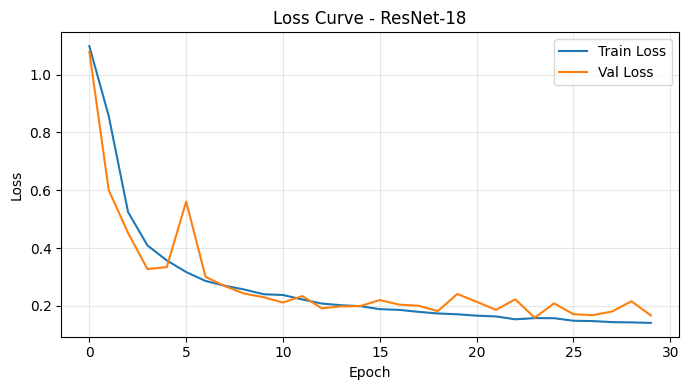

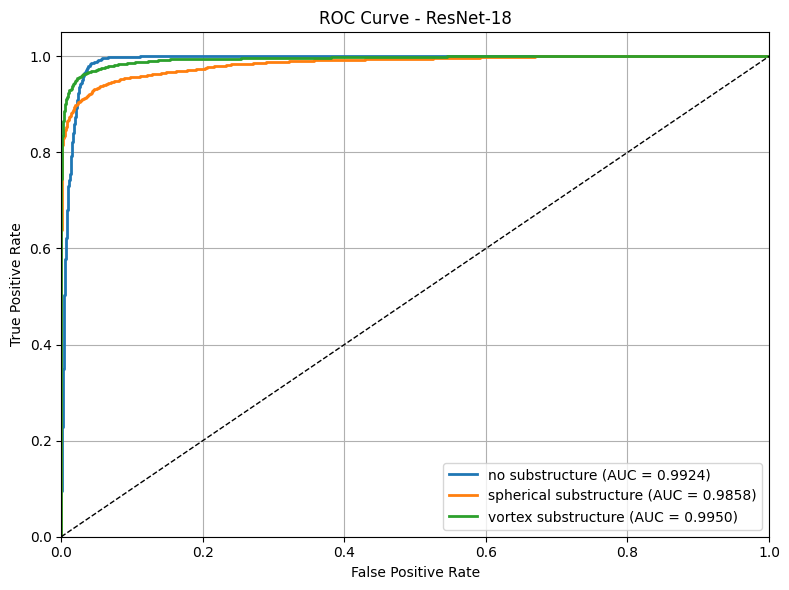

In [6]:
plot_history(trainloss_r18, valloss_r18, 'ResNet-18')
fpr_r18 = {i: roc_curve(y_true == i, y_scores[:, i])[0] for i in range(NUM_CLASSES)}
tpr_r18 = {i: roc_curve(y_true == i, y_scores[:, i])[1] for i in range(NUM_CLASSES)}
plot_roc(fpr_r18, tpr_r18, {i: best_per_class_r18[i] for i in range(NUM_CLASSES)}, 'ResNet-18')

In [7]:
model_r34 = models.resnet34(weights='IMAGENET1K_V1')
model_r34.fc = nn.Linear(model_r34.fc.in_features, NUM_CLASSES)
model_r34 = model_r34.to(DEVICE)

criterion_r34 = nn.CrossEntropyLoss()
optimizer_r34 = optim.Adam([
    {'params': [p for n, p in model_r34.named_parameters() if 'fc' not in n], 'lr': 1e-4},
    {'params': model_r34.fc.parameters(), 'lr': 1e-3}
], weight_decay=1e-4)

scheduler_r34 = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer_r34, T_max=30)

model_r34, history_r34 = train_model(
    model_r34, train_ld, val_ld, criterion_r34, optimizer_r34, 30, 'resnet34')

Downloading: "https://download.pytorch.org/models/resnet34-b627a593.pth" to /root/.cache/torch/hub/checkpoints/resnet34-b627a593.pth


100%|██████████| 83.3M/83.3M [00:00<00:00, 226MB/s] 
Epoch 1/30 [Val]: 100%|██████████| 94/94 [00:04<00:00, 19.36it/s]


Epoch 1/30:  Train Loss: 0.7153  Val Loss: 0.3873  Val Acc: 0.8550
Best model saved: 0.8550


Epoch 2/30 [Val]: 100%|██████████| 94/94 [00:01<00:00, 53.31it/s]


Epoch 2/30:  Train Loss: 0.3511  Val Loss: 0.2728  Val Acc: 0.8993
Best model saved: 0.8993


...

Epoch 28/30:  Train Loss: 0.0844  Val Loss: 0.1377  Val Acc: 0.9553


Epoch 29/30 [Val]: 100%|██████████| 94/94 [00:01<00:00, 51.91it/s]


Epoch 29/30:  Train Loss: 0.0816  Val Loss: 0.1841  Val Acc: 0.9437


Epoch 30/30 [Val]: 100%|██████████| 94/94 [00:01<00:00, 51.49it/s]

Epoch 30/30:  Train Loss: 0.0804  Val Loss: 0.2022  Val Acc: 0.9470


Evaluating: 100%|██████████| 235/235 [00:04<00:00, 53.76it/s]


Accuracy: 0.9479  Macro AUC: 0.9908


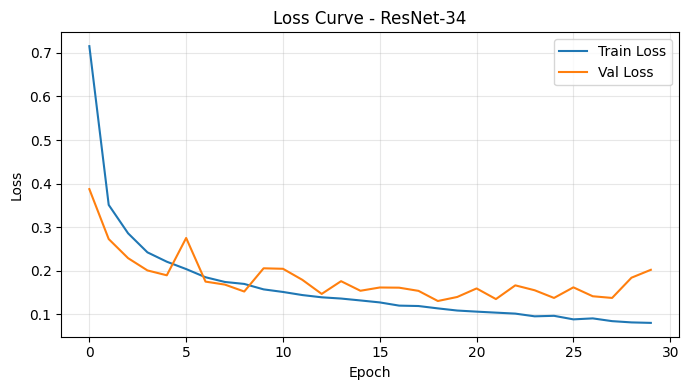

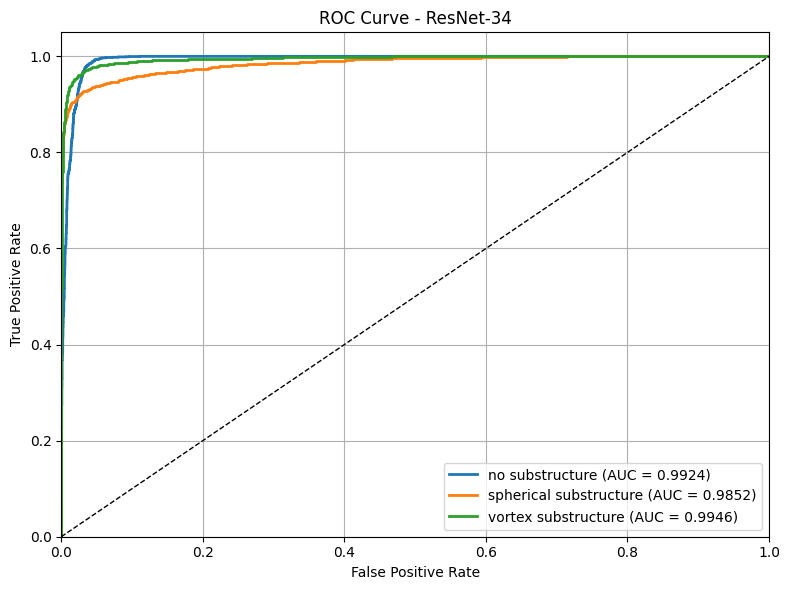

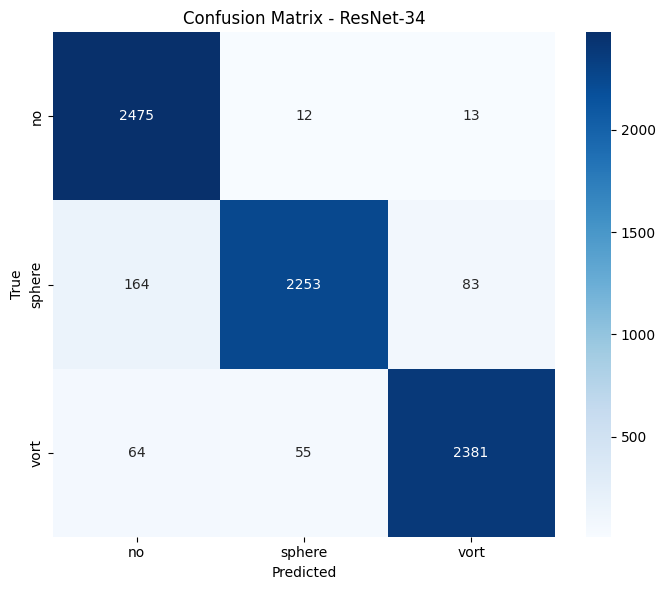

In [8]:
acc_r34, macro_auc_r34, roc_auc_r34, fpr_r34, tpr_r34, labels_r34, preds_r34, _ = \
    evaluate_model(model_r34, test_ld, criterion_r34)
plot_history(history_r34['train_loss'], history_r34['val_loss'], 'ResNet-34')
plot_roc(fpr_r34, tpr_r34, roc_auc_r34, 'ResNet-34')
plot_cm(labels_r34, preds_r34, 'ResNet-34')

In [9]:
model_efnet = models.efficientnet_b3(weights='IMAGENET1K_V1')
model_efnet.classifier[1] = nn.Linear(model_efnet.classifier[1].in_features, NUM_CLASSES)

criterion_efnet = nn.CrossEntropyLoss()
optimizer_efnet = optim.Adam(model_efnet.parameters(), lr=0.001)

model_efnet, history_efnet = train_model(
    model_efnet, train_ld, val_ld, criterion_efnet, optimizer_efnet, 30, 'efficientnet_b3')

Downloading: "https://download.pytorch.org/models/efficientnet_b3_rwightman-b3899882.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b3_rwightman-b3899882.pth


100%|██████████| 47.2M/47.2M [00:00<00:00, 145MB/s] 
Epoch 1/30 [Val]: 100%|██████████| 94/94 [00:01<00:00, 53.38it/s]


Epoch 1/30:  Train Loss: 0.7672  Val Loss: 0.3928  Val Acc: 0.8507
Best model saved: 0.8507


Epoch 2/30 [Val]: 100%|██████████| 94/94 [00:01<00:00, 51.03it/s]


Epoch 2/30:  Train Loss: 0.3806  Val Loss: 0.4143  Val Acc: 0.8697
Best model saved: 0.8697


...

Epoch 28/30:  Train Loss: 0.0996  Val Loss: 0.1318  Val Acc: 0.9553


Epoch 29/30 [Val]: 100%|██████████| 94/94 [00:01<00:00, 51.34it/s]


Epoch 29/30:  Train Loss: 0.0963  Val Loss: 0.1285  Val Acc: 0.9590
Best model saved: 0.9590


Epoch 30/30 [Val]: 100%|██████████| 94/94 [00:01<00:00, 53.75it/s]

Epoch 30/30:  Train Loss: 0.0925  Val Loss: 0.1467  Val Acc: 0.9547


Evaluating: 100%|██████████| 235/235 [00:04<00:00, 54.94it/s]


Accuracy: 0.9605  Macro AUC: 0.9941


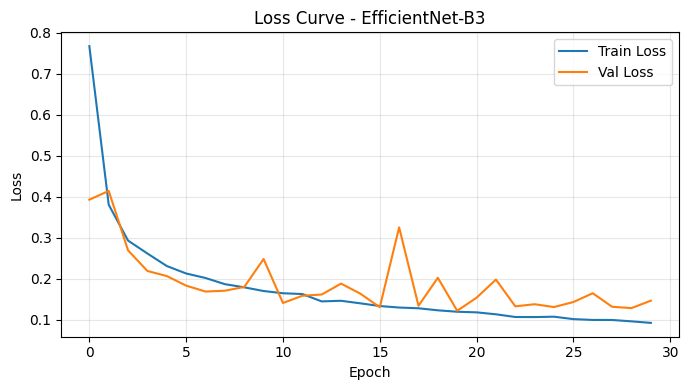

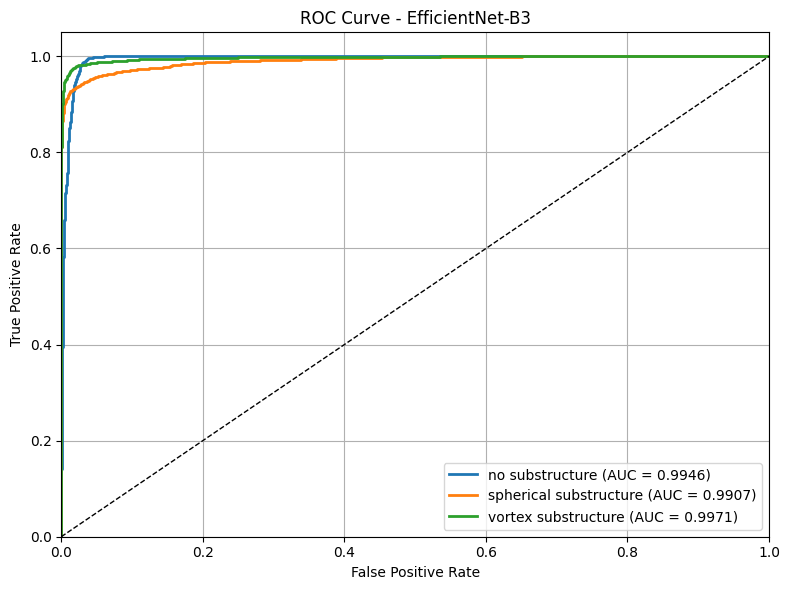

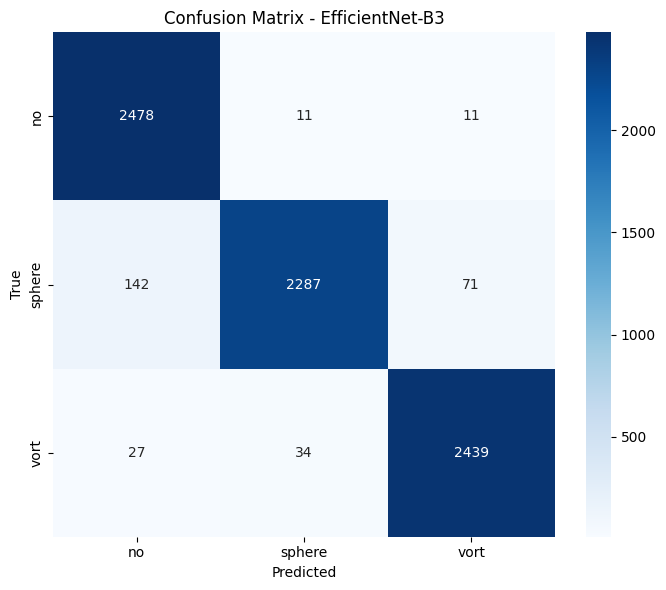

In [10]:
acc_efnet, macro_auc_efnet, roc_auc_efnet, fpr_efnet, tpr_efnet, labels_efnet, preds_efnet, _ = \
    evaluate_model(model_efnet, test_ld, criterion_efnet)
plot_history(history_efnet['train_loss'], history_efnet['val_loss'], 'EfficientNet-B3')
plot_roc(fpr_efnet, tpr_efnet, roc_auc_efnet, 'EfficientNet-B3')
plot_cm(labels_efnet, preds_efnet, 'EfficientNet-B3')

In [11]:
results = {
    'ResNet-18':       {'Accuracy': best_acc_r18,  'Macro AUC': best_auc_r18,
                        'No AUC': best_per_class_r18[0], 'Sphere AUC': best_per_class_r18[1], 'Vortex AUC': best_per_class_r18[2]},
    'ResNet-34':       {'Accuracy': acc_r34,        'Macro AUC': macro_auc_r34,
                        'No AUC': roc_auc_r34[0],   'Sphere AUC': roc_auc_r34[1],   'Vortex AUC': roc_auc_r34[2]},
    'EfficientNet-B3': {'Accuracy': acc_efnet,      'Macro AUC': macro_auc_efnet,
                        'No AUC': roc_auc_efnet[0], 'Sphere AUC': roc_auc_efnet[1], 'Vortex AUC': roc_auc_efnet[2]},
}

df = pd.DataFrame(results).T
print('=' * 70)
print('MODEL COMPARISON')
print('=' * 70)
print(df.to_string(float_format=lambda x: f'{x:.4f}'))
print('=' * 70)

MODEL COMPARISON
                 Accuracy  Macro AUC  No AUC  Sphere AUC  Vortex AUC
ResNet-18          0.9443     0.9911  0.9924      0.9858      0.9950
ResNet-34          0.9479     0.9908  0.9924      0.9852      0.9946
EfficientNet-B3    0.9605     0.9941  0.9946      0.9907      0.9971


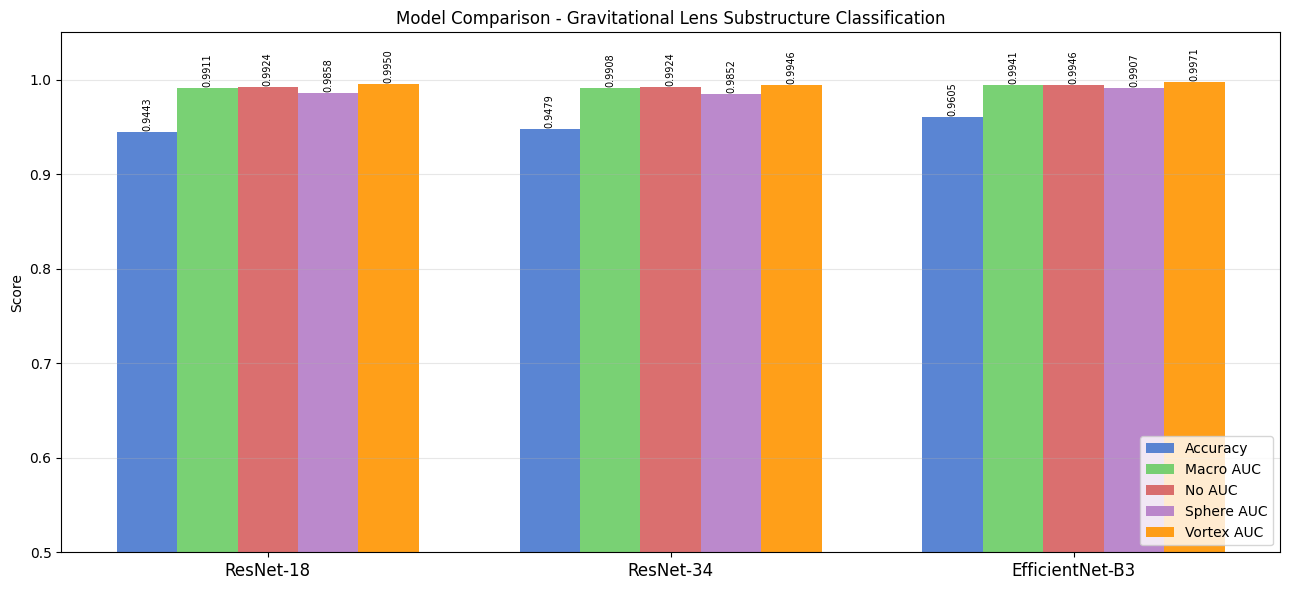

In [12]:
model_names = list(results.keys())
metrics     = ['Accuracy', 'Macro AUC', 'No AUC', 'Sphere AUC', 'Vortex AUC']
colors      = ['#4878CF', '#6ACC65', '#D65F5F', '#B47CC7', '#FF9500']
x           = np.arange(len(model_names))
w           = 0.15

fig, ax = plt.subplots(figsize=(13, 6))
for idx, (metric, color) in enumerate(zip(metrics, colors)):
    vals = [results[m][metric] for m in model_names]
    bars = ax.bar(x + (idx - 2) * w, vals, w, label=metric, color=color, alpha=0.9)
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.001,
                f'{val:.4f}', ha='center', va='bottom', fontsize=7, rotation=90)
ax.set_xticks(x)
ax.set_xticklabels(model_names, fontsize=12)
ax.set_ylim([0.5, 1.05])
ax.set_ylabel('Score')
ax.set_title('Model Comparison - Gravitational Lens Substructure Classification')
ax.legend(loc='lower right')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()